Check the distribution of ground truth ranking metrics (min normalized MCES, Tanimoto distance, unique scaffold) for val and test folds.

1. Import data and all needed libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [10]:
MASSSPECGYM_NOVELTY_ROOT = Path.cwd().parent.absolute()
SPLIT_PATH = MASSSPECGYM_NOVELTY_ROOT / 'data/cluster_split.tsv' 

In [11]:
print('Import cluster split with ground truth rankings')
split = pd.read_csv(SPLIT_PATH, sep='\t')
print('Cluster split imported')
print(split[['fold', 'min_mces', 'tanimoto_distance', 'unique_scaffold', 'fragment_coverage']].head())

Import cluster split with ground truth rankings
Cluster split imported
    fold  min_mces  tanimoto_distance unique_scaffold  fragment_coverage
0  train       NaN                NaN             NaN                NaN
1  train       NaN                NaN             NaN                NaN
2  train       NaN                NaN             NaN                NaN
3  train       NaN                NaN             NaN                NaN
4  train       NaN                NaN             NaN                NaN


2. Helper to plot distribution of a numeric metric for a given fold

In [12]:
def plot_metric_distribution(split, metric, fold, xlabel, bins=23, step=None):
    print(f'Get distribution of {metric} for {fold} fold')
    values = split.loc[split['fold'] == fold, metric].dropna().to_numpy()
    print(f'Got {len(values)} values, min={values.min():.4f}, max={values.max():.4f}, mean={values.mean():.4f}')
    plt.hist(values, color='palevioletred', ec='black', bins=bins)
    if step is not None:
        plt.xticks(np.arange(0, values.max() + step, step=step))
    plt.xlabel(xlabel)
    plt.ylabel('Number of molecules')
    plt.title(f'{metric} distribution for {fold} fold')
    plt.show()

3. Helper to plot unique scaffold counts (boolean metric) for a given fold

In [13]:
def plot_scaffold_distribution(split, fold):
    print(f'Get unique scaffold distribution for {fold} fold')
    values = split.loc[split['fold'] == fold, 'unique_scaffold'].dropna().astype(bool)
    counts = values.value_counts().reindex([False, True], fill_value=0)
    print(f'Unique scaffolds: {counts[True]} / {len(values)} ({counts[True] / len(values):.1%})')
    plt.bar(['shared', 'unique'], counts.values, color='palevioletred', ec='black')
    plt.ylabel('Number of molecules')
    plt.title(f'Unique scaffold distribution for {fold} fold')
    plt.show()

4. Min normalized MCES distance distribution

Get distribution of min_mces for val fold
Got 2889 values, min=1.0000, max=24.0000, mean=3.9081


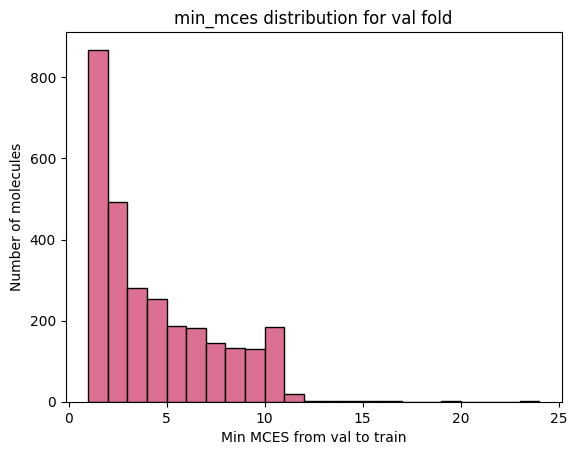

In [14]:
plot_metric_distribution(split, 'min_mces', 'val', 'Min MCES from val to train')

Get distribution of min_mces for test fold
Got 2889 values, min=1.0000, max=23.5000, mean=3.9683


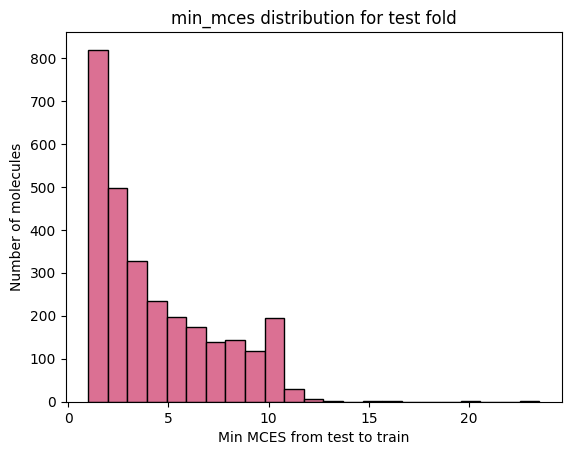

In [15]:
plot_metric_distribution(split, 'min_mces', 'test', 'Min MCES from test to train')

5. Tanimoto distance (1 - max Tanimoto similarity to train) distribution

Get distribution of tanimoto_distance for val fold
Got 2889 values, min=0.0000, max=0.8750, mean=0.3331


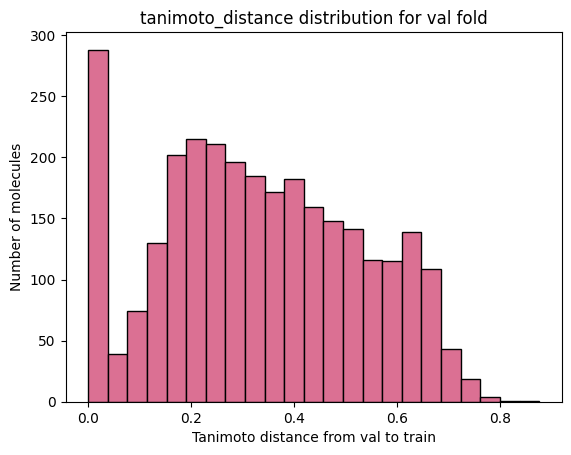

In [16]:
plot_metric_distribution(split, 'tanimoto_distance', 'val', 'Tanimoto distance from val to train')

Get distribution of tanimoto_distance for test fold
Got 2889 values, min=0.0000, max=0.7966, mean=0.3381


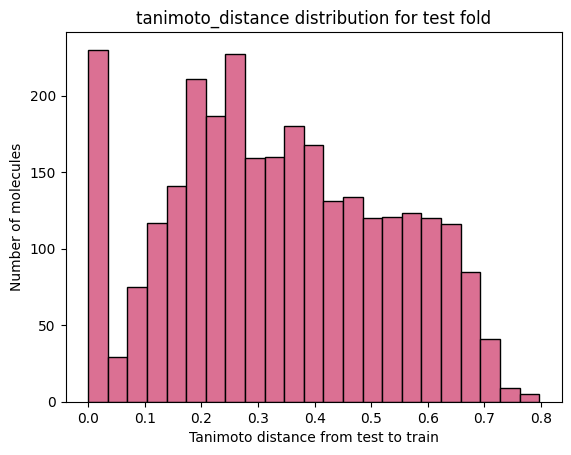

In [17]:
plot_metric_distribution(split, 'tanimoto_distance', 'test', 'Tanimoto distance from test to train')

6. Unique scaffold distribution

Get unique scaffold distribution for val fold
Unique scaffolds: 1018 / 2889 (35.2%)


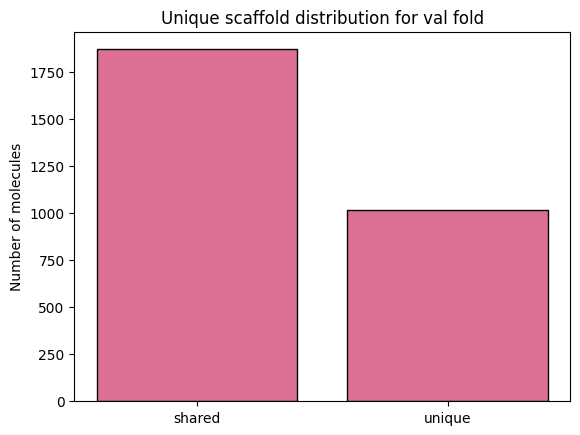

In [18]:
plot_scaffold_distribution(split, 'val')

Get unique scaffold distribution for test fold
Unique scaffolds: 1044 / 2889 (36.1%)


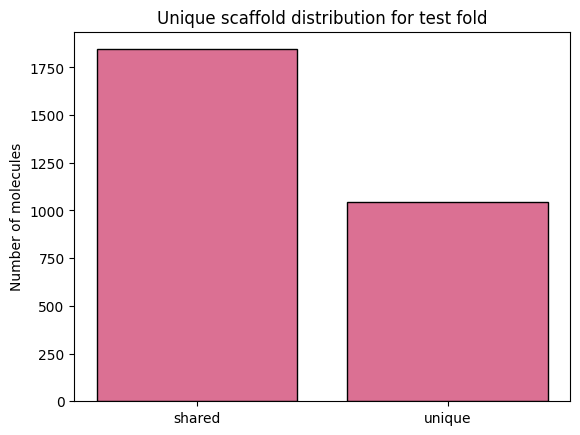

In [19]:
plot_scaffold_distribution(split, 'test')

7. Fragment coverage distribution (1 - fragment coverage)

In [21]:
# Derive 1 - fragment_coverage: fraction of the molecule NOT captured by library fragments
split['uncovered_fraction'] = 1 - split['fragment_coverage']
print('Derived uncovered_fraction = 1 - fragment_coverage')

Derived uncovered_fraction = 1 - fragment_coverage


Get distribution of uncovered_fraction for val fold
Got 2889 values, min=0.0000, max=1.0000, mean=0.0848


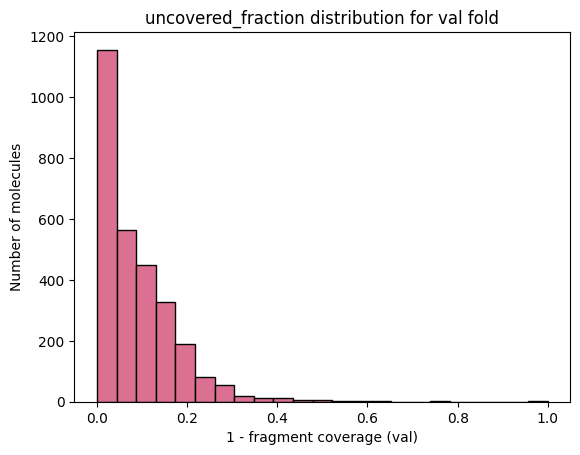

In [22]:
plot_metric_distribution(split, 'uncovered_fraction', 'val', '1 - fragment coverage (val)')

Get distribution of uncovered_fraction for test fold
Got 2889 values, min=0.0000, max=1.0000, mean=0.0867


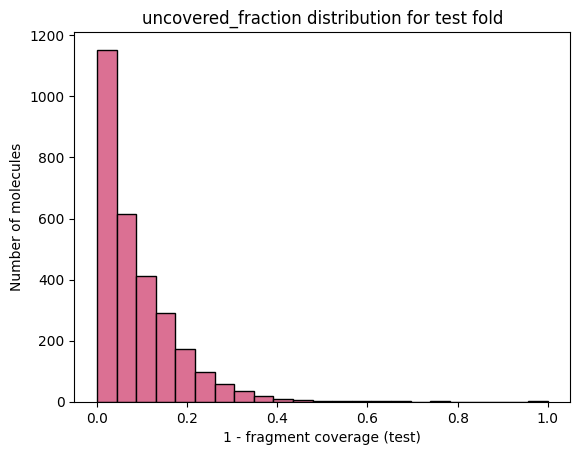

In [23]:
plot_metric_distribution(split, 'uncovered_fraction', 'test', '1 - fragment coverage (test)')

8. Overlap of "novel" molecules across metrics (Venn). For each numeric ranking metric we take the top-k% (default 10%) as novel; `unique_scaffold` is already boolean so it needs no threshold. The Venn shows how much the metrics agree on which molecules are novel.

In [24]:
def select_top_k(split, metric, fold, k=0.1):
    """Set of SMILES in `fold` whose `metric` is in the top-k fraction (most novel).
    For all ranking metrics here higher = more novel, so the threshold is the (1-k) quantile."""
    sub = split.loc[split['fold'] == fold, ['smiles', metric]].dropna()
    k = int(2887 * k)
    sub = sub.sort_values(by=metric, ascending=False)
    selected = sub['smiles'].to_list()[:k]
    threshold = sub[metric].iloc[k - 1] if len(selected) > 0 else float('nan')
    print(f'{fold} | {metric}: top {k} -> threshold={threshold:.4f}, {len(selected)}/{len(sub)} molecules')
    return set(selected)


def select_unique_scaffold(split, fold):
    """Set of SMILES in `fold` flagged as having a unique scaffold (boolean, no threshold)."""
    sub = split[split['fold'] == fold]
    mask = sub['unique_scaffold'].fillna(False).astype(bool)
    selected = sub.loc[mask, 'smiles']
    print(f'{fold} | unique_scaffold: {len(selected)}/{len(sub)} molecules')
    return set(selected)

def select_mces_threshold(split, fold, threshold=10):
    """Set of SMILES in `fold` flagged novel by MCES using the SAME rule as the
    ground-truth labels: min MCES distance to train >= threshold (default 10),
    regardless of what fraction of the fold that is."""
    sub = split.loc[split['fold'] == fold, ['smiles', 'min_mces']].dropna()
    selected = sub.loc[sub['min_mces'].astype(float) >= threshold, 'smiles']
    print(f'{fold} | min_mces >= {threshold}: {len(selected)}/{len(sub)} molecules')
    return set(selected)


In [25]:
# Build the "novel molecule" sets for a fold and draw their overlap as a Venn diagram.
# venn (pyvenn) supports 4-6 sets; matplotlib_venn only goes up to 3. Install with: pip install venn
from venn import venn


def make_venn(split, fold, k=0.1):
    sets = {
        'MCES':          select_mces_threshold(split, fold, threshold=10),  # fixed cutoff, matches ground-truth label
        'Tanimoto':      select_top_k(split, 'tanimoto_distance', fold, k),
        '1 - coverage':  select_top_k(split, 'uncovered_fraction', fold, k),
        'uniq scaffold': select_unique_scaffold(split, fold),         # boolean, no threshold
    }
    venn(sets)
    plt.title(f'Overlap of novel molecules ({fold} fold, top {k:.0%})')
    plt.show()
    return sets

val | min_mces >= 10: 218/2889 molecules
val | tanimoto_distance: top 288 -> threshold=0.6154, 288/2889 molecules
val | uncovered_fraction: top 288 -> threshold=0.2000, 288/2889 molecules
val | unique_scaffold: 1018/2889 molecules


C:\Users\user\AppData\Local\Temp\ipykernel_33184\3904806599.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = sub['unique_scaffold'].fillna(False).astype(bool)


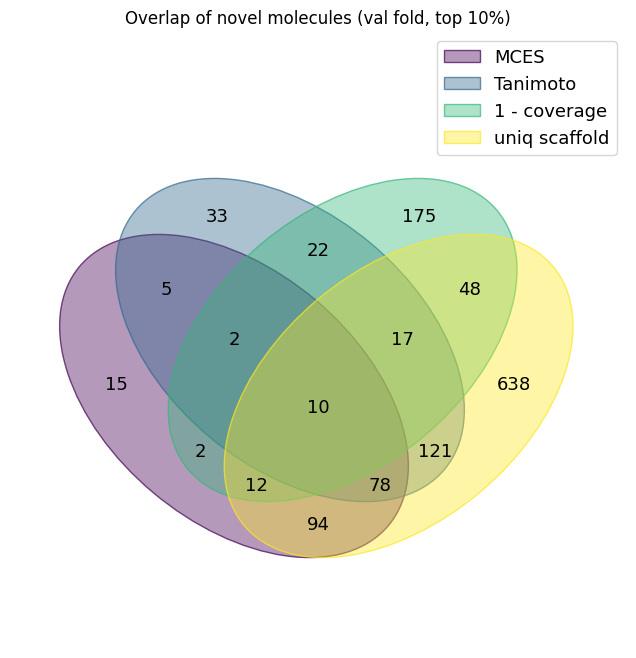

In [26]:
val_novel_sets = make_venn(split, 'val', k=0.1)

test | min_mces >= 10: 237/2889 molecules
test | tanimoto_distance: top 288 -> threshold=0.6154, 288/2889 molecules
test | uncovered_fraction: top 288 -> threshold=0.2000, 288/2889 molecules
test | unique_scaffold: 1044/2889 molecules


C:\Users\user\AppData\Local\Temp\ipykernel_33184\3904806599.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = sub['unique_scaffold'].fillna(False).astype(bool)


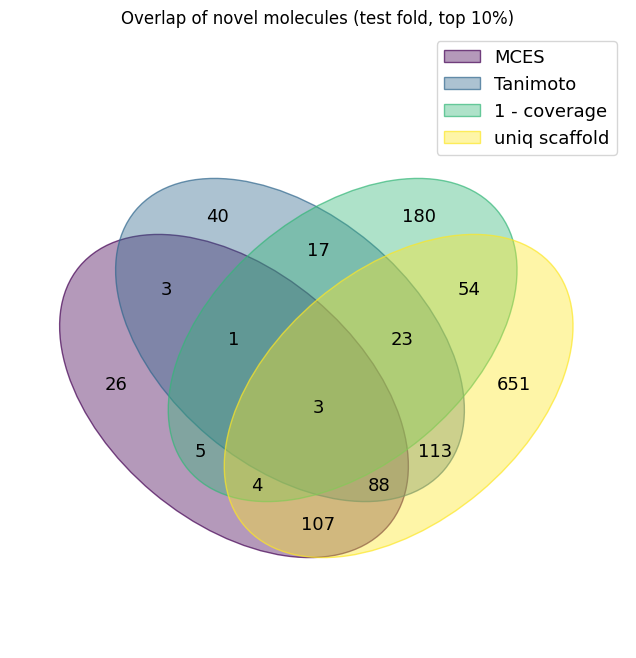

In [27]:
test_novel_sets = make_venn(split, 'test', k=0.1)